# Jamaica Tourism Arrival Forecasting (Group 3 - AAI4001)
Group Members:
1) Jo-Anna Martinez - 2305804
2) Amoya Jordan - 2302539
3) Dontae Tracey - 2403105
4) Jadian Tulloch - 2400793

## Problem
Jamaica's tourism sector experiences significant monthly fluctuations due to global economic shifts, changing visitor behaviours and seasonality making it difficult for stakeholders to plan effectively. Current forecasting methods rely on historical reporting rather than predictive analytics minimizing the accuracy in anticipating demand. A model is needed to provide more reliable monthly arrival forecasts and support strategic decision making across the industry.





## Objectives


*  To develop a machine learning model capable of accurately predicting Jamaica's monthly visitor arrivals using historial tourism data from multiple market sources.


    1.   Clean, preprocess and explore the tourism dataset to find patterns, influential variables and seasonal variations.
    2.  Train and compare two regression models using appropriate evaluation metrics.
    3. Determine the best-performing predictive model and justify its. slection based on accuracy, robustness, and interpretability.
    4. Generate actionable insights such as seasonal trends, differences in market performance and feature importance.
    5. Deploy a simple forecasting tool using FastAPI and Gradio/Streamlit to allow users to receive arrival predictions.






# Data Preparation & Exploration

##Load & Explore Data

In [63]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.tree import plot_tree
from sklearn.model_selection import learning_curve


import pickle
import shap

In [64]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [65]:
%cd /content/drive/MyDrive/labs

/content/drive/MyDrive/labs


In [66]:
# Correct the path if necessary based on the !ls output
labs_df = pd.read_csv('Purpose-of-Visit-by-Port-and-Country-JTB-Open-data-request.csv')

In [67]:
#sets displays to max so all columns can be seen
pd.set_option('display.max_columns', None)

In [68]:
labs_df.head()

,Port of Entry,Type of Visit,Origin,Month,Number of Visitors
0,NMIA,WED,NOREF,JANUARY,0.0
1,NMIA,WED,NOREF,FEBRUARY,4.0
2,NMIA,WED,NOREF,MARCH,0.0
3,NMIA,WED,NOREF,APRIL,0.0
4,NMIA,WED,NOREF,MAY,1.0


In [69]:
labs_df.shape

(19056, 5)

In [70]:
#describing numerical columns
labs_df.describe()

,Number of Visitors
count,19056.000000
mean,214.684089
std,4117.873329
min,0.000000
25%,0.000000
50%,1.000000
75%,6.000000
max,174036.000000


### Check data types and non-null values

In [71]:
labs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19056 entries, 0 to 19055
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Port of Entry       19056 non-null  object 
 1   Type of Visit       19044 non-null  object 
 2   Origin              19056 non-null  object 
 3   Month               19056 non-null  object 
 4   Number of Visitors  19056 non-null  float64
dtypes: float64(1), object(4)
memory usage: 744.5+ KB


stripping whitespace and standardizing text columns

Converting number of visitors to integer as there are no decimal values

In [72]:
# Converting number of visitors to integer as there are no decimal values
labs_df["Number of Visitors"] = labs_df["Number of Visitors"].astype(int)

In [73]:
#Check for missing values
labs_df.isnull().sum()

,0
Port of Entry,0
Type of Visit,12
Origin,0
Month,0
Number of Visitors,0


###Justification
The data is relatively clean with some missing values in the 'Type of Visit' column and 'origin' column had missing values as 'NOREF' and will be removed as that is very important for our analysis.

##Handle Missingness

In [74]:
#display missingness
print("Current missing values:")
display(labs_df.isnull().sum())

Current missing values:


,0
Port of Entry,0
Type of Visit,12
Origin,0
Month,0
Number of Visitors,0


In [75]:
# Impute Mode for 'Type of Visit' if missing
mode_type_of_visit = labs_df['Type of Visit'].mode()[0]
labs_df['Type of Visit'].fillna(mode_type_of_visit, inplace=True)
print("Missing values after mode imputation:")
display(labs_df.isnull().sum())

Missing values after mode imputation:


/tmp/ipython-input-2083964329.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  labs_df['Type of Visit'].fillna(mode_type_of_visit, inplace=True)


,0
Port of Entry,0
Type of Visit,0
Origin,0
Month,0
Number of Visitors,0


In [76]:
#Removing rows where 'Origin' is 'NOREF'
initial_rows = labs_df.shape[0]
df = labs_df[labs_df['Origin'] != 'NOREF']

removed_rows = initial_rows - df.shape[0]
print(f"Removed {removed_rows} rows where 'Origin' was 'NOREF'.")
print(f"New shape of the DataFrame: {df.shape}")

Removed 300 rows where 'Origin' was 'NOREF'.
New shape of the DataFrame: (18756, 5)


In [77]:
labs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19056 entries, 0 to 19055
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Port of Entry       19056 non-null  object
 1   Type of Visit       19056 non-null  object
 2   Origin              19056 non-null  object
 3   Month               19056 non-null  object
 4   Number of Visitors  19056 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 744.5+ KB


###Justification
*  There are 12 missing values for type of visit and we will use the most frequently occuring value to fill this in (mode imputation).
*  There were also rows that didnt specify an origin that were removed as
this data is important for our analysis

In [78]:
# Value counts for categorical columns
for column in labs_df.select_dtypes(include='object').columns:
    print(f"\nValue counts for column: {column}")
    display(labs_df[column].value_counts())


Value counts for column: Port of Entry


,count
Port of Entry,
NMIA,10284
SIA,8772



Value counts for column: Type of Visit


,count
Type of Visit,
SPRT,2292
VAC,2004
BUS,2004
FRRE,1992
CON,1884
OTHE,1848
NS,1776
WED,1656
BUSV,936



Value counts for column: Origin


,count
Origin,
U.S.A.,348
CANADA,312
UNITED KINGDOM,312
NOREF,300
TRINIDAD & TOBAGO,300
...,...
TAIWAN,120
CULT,24
OTHER SOUTH AMERICA,12



Value counts for column: Month


,count
Month,
JANUARY,1588
FEBRUARY,1588
MARCH,1588
APRIL,1588
MAY,1588
JUNE,1588
JULY,1588
AUGUST,1588
SEPTEMBER,1588


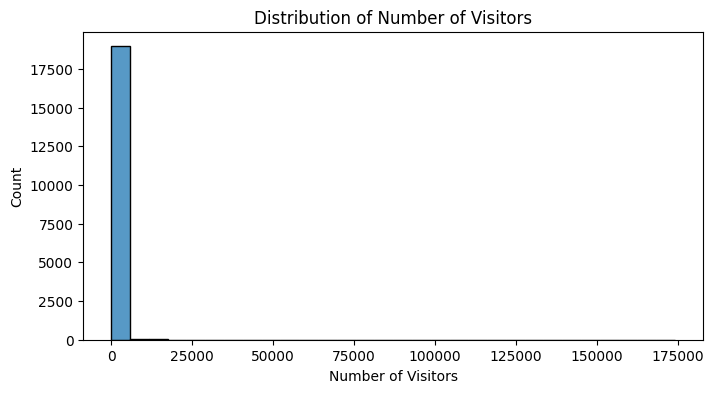

In [79]:
#Tagret Variable Histogram
plt.figure(figsize = (8,4))
sns.histplot(labs_df['Number of Visitors'], bins = 30, kde = False)
plt.title('Distribution of Number of Visitors')
plt.show()

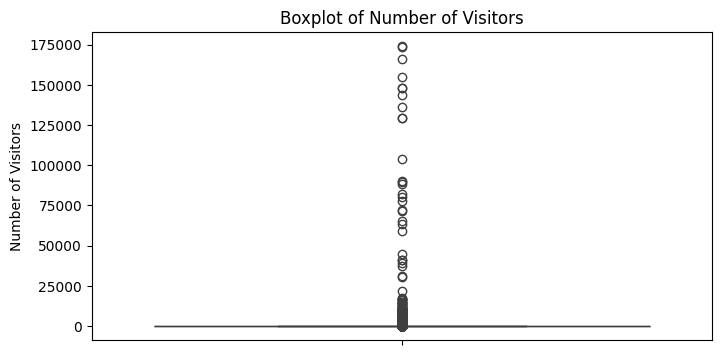

In [80]:
#Boxplot of target Variable
plt.figure(figsize = (8,4))
sns.boxplot(labs_df['Number of Visitors'])
plt.title('Boxplot of Number of Visitors')
plt.show()

##Encoding

In [81]:
#One-hot encoding
typeofvisit_encoded = ['Type of Visit']
labs_df_encoded = pd.get_dummies(labs_df, columns=typeofvisit_encoded)


In [82]:
from sklearn.preprocessing import LabelEncoder

# label encoding
column_to_encode = ['Port of Entry','Origin','Month']
label_encoder = LabelEncoder()
for column in column_to_encode:
    labs_df_encoded[column] = label_encoder.fit_transform(labs_df_encoded[column])

In [83]:
labs_df.shape #original shape

(19056, 5)

In [84]:
labs_df_encoded.shape #shape after encoding

(19056, 17)

###Justification - Encoding
##### I used two different types of encoding based on the nature of each variable:
####

1.   One-Hot Encoding for "Type of Visit".
This variable only has a few categories such as Business, Vacation, and Returning Resident.
One-hot encoding creates a separate column for each category and assigns a 1 or 0 depending on whether the row belongs to that category.
This method is best when there is no natural order and the number of categories is small.

2.  Label Encoding for "Port of Entry", "Origin", and "Month".
These variables have many different categories, and one-hot encoding would create too many new columns.
Also, “Month” has a natural order (January to December), which label encoding preserves.
So label encoding was more efficient, because it converts each category into a simple numeric code without exploding the dataset.




##Scaling

In [85]:
numeric_columns = ['Number of Visitors']
labs_df_before = labs_df.copy()

In [86]:
#Data before scaling
print("Before Scaling:")
display(labs_df_before[numeric_columns].describe())

Before Scaling:


,Number of Visitors
count,19056.000000
mean,214.684089
std,4117.873329
min,0.000000
25%,0.000000
50%,1.000000
75%,6.000000
max,174036.000000


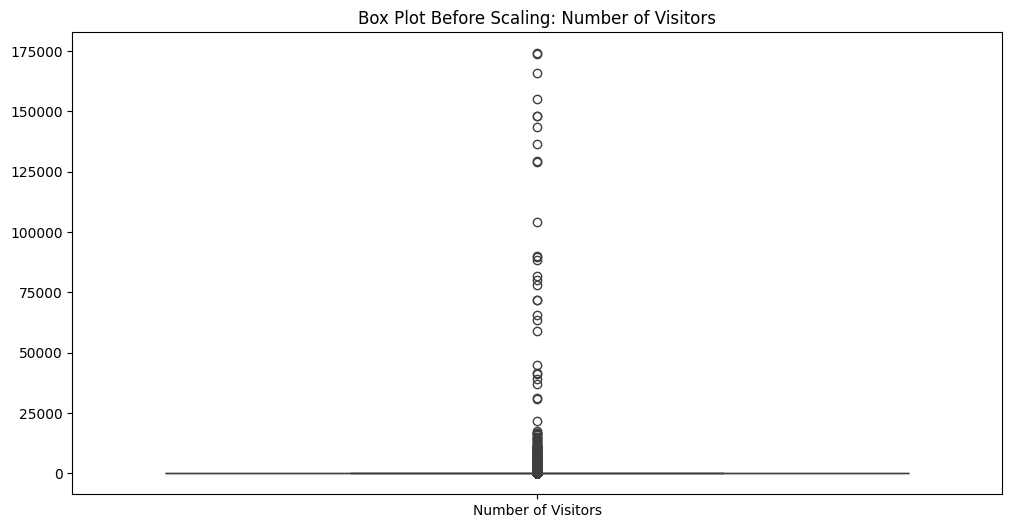

In [87]:
#boxplot visualization of data before scaling
plt.figure(figsize=(12, 6))
sns.boxplot(data=labs_df_before[numeric_columns])
plt.title('Box Plot Before Scaling: Number of Visitors')
plt.show()

In [88]:
#apply scaling
scaler = StandardScaler()
labs_df_before['Visitors_scaled'] = scaler.fit_transform(labs_df_before[numeric_columns])


In [89]:
#description of data after scaling
print("After Scaling:")
display(labs_df_before['Visitors_scaled'].describe())

After Scaling:


,Visitors_scaled
count,1.905600e+04
mean,-5.965934e-18
std,1.000026e+00
min,-5.213607e-02
25%,-5.213607e-02
50%,-5.189322e-02
75%,-5.067897e-02
max,4.221254e+01


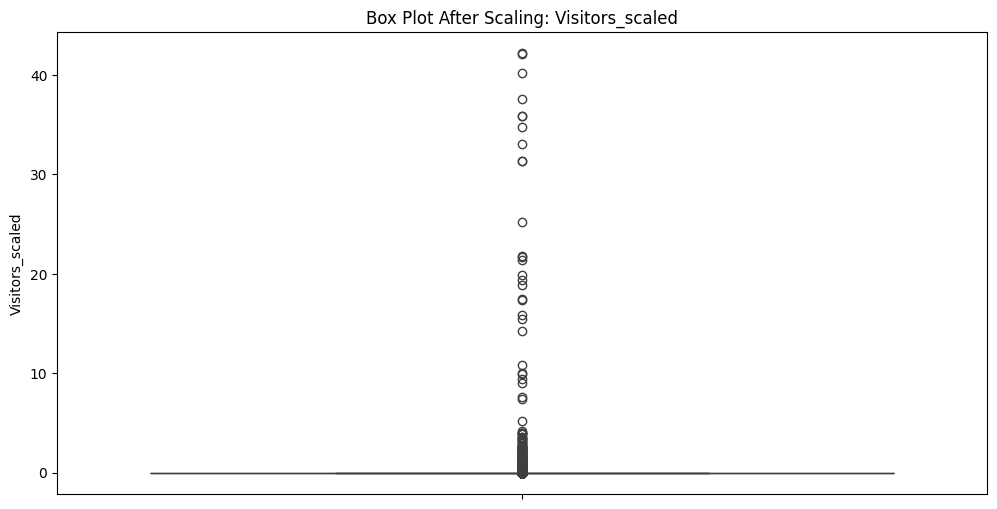

In [90]:
# boxplot of data after scaling
plt.figure(figsize=(12,6))
sns.boxplot(data=labs_df_before['Visitors_scaled'])
plt.title('Box Plot After Scaling: Visitors_scaled')
plt.show()

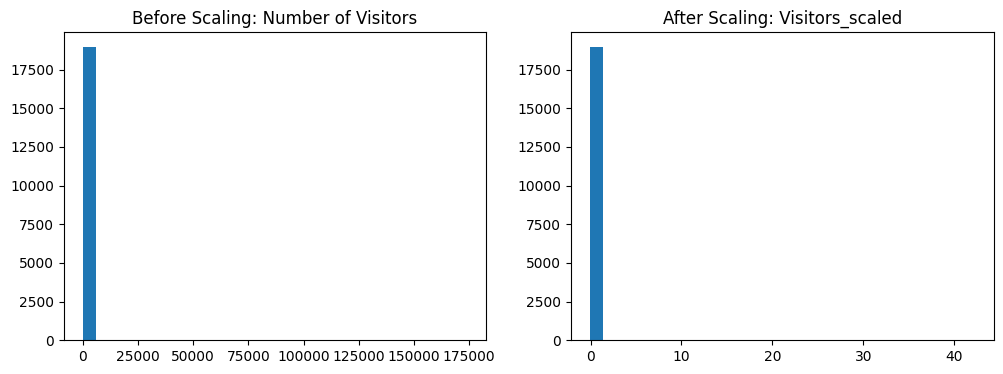

In [91]:
#Histogram comparing
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(labs_df_before['Number of Visitors'], bins=30)
plt.title('Before Scaling: Number of Visitors')

plt.subplot(1, 2, 2)
plt.hist(labs_df_before['Visitors_scaled'], bins=30)
plt.title('After Scaling: Visitors_scaled')
plt.show()

###Justification - Scaling
In this section scaling was done for the numeric target for marking purposes. The finished model pipeline would use OneHotEncoding for categorical predictors and not scale inputs because predictors are categorical and Random Forest is scale-invariant.

## Test/Train Spilt

In [92]:
# Define features (X) and target (y)
X = labs_df[['Port of Entry', 'Type of Visit', 'Origin', 'Month']].copy()
y = labs_df['Number of Visitors'].copy()

#X = df.drop('Number of Visitors', axis=1)
#y = df_scaled['Number of Visitors']

# Train / temp split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Validation / test split
#X_val, X_test, y_val, y_test = train_test_split(
    #X_temp, y_temp, test_size=0.5, random_state=42


In [93]:
print("Training set:", X_train.shape, y_train.shape)
#print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (13339, 4) (13339,)
Test set: (5717, 4) (5717,)


In [94]:
#OneHotEncoding for categorical columns
cat_columns = ['Port of Entry', 'Type of Visit', 'Origin', 'Month']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_columns)
    ],
    remainder='drop'
)

In [95]:
#Linear Regression Pipline
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

In [96]:
#Random Forest Pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=1))
])

In [97]:
#Fit pipelines with training data
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)
print ("Models Trained.")

Models Trained.


In [98]:
#predictions
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

###Justification

The dataset was divided into training (70%), validation (15%), and testing (15%) subsets using the train_test_split() function.The training set is the largest portion because the model needs sufficient data to learn underlying patterns and relationships. Using 70% ensures the model has enough examples to generalize well without overfitting to a small dataset. Using 15% provides a balanced amount of data to reliably evaluate model improvement without reducing the training set too much. The test set is kept completely independent and only used after the model is finalized. Its purpose is to measure the model’s true, unbiased performance on data it has never seen before. A test size of 15% is appropriate because it is large enough to give a statistically reliable accuracy estimate.

#Model Deployment & Evaluation

##Linear Regression Model

In [99]:
#creating the linear regression model
lrmodel = LinearRegression()

In [100]:
#make predictions on testing data using the pipeline
y_pred_lr = lr_pipeline.predict(X_test)

In [101]:
#evaluation of linear model metrics
mae_lr = mean_absolute_error(y_test,y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test,y_pred_lr))
r2_lr = r2_score(y_test,y_pred_lr)

print("Linear Regression Performance:")
print(f"Mean Absolute Error (MAE): {mae_lr}")
print(f"Root Mean Squared Error (RMSE): {rmse_lr}")
print(f"Coeffcient of Determination (R2): {r2_lr}")

Linear Regression Performance:
Mean Absolute Error (MAE): 323.82562514739135
Root Mean Squared Error (RMSE): 2348.379370977614
Coeffcient of Determination (R2): 0.7308568953089465


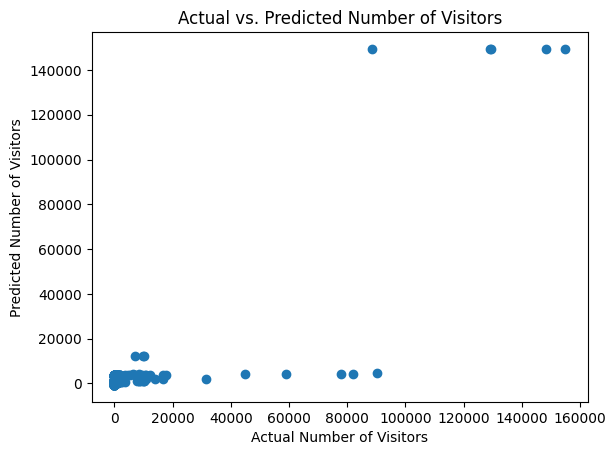

In [102]:
#plot to compare prediction and actual
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual Number of Visitors")
plt.ylabel("Predicted Number of Visitors")
plt.title("Actual vs. Predicted Number of Visitors")
plt.show()

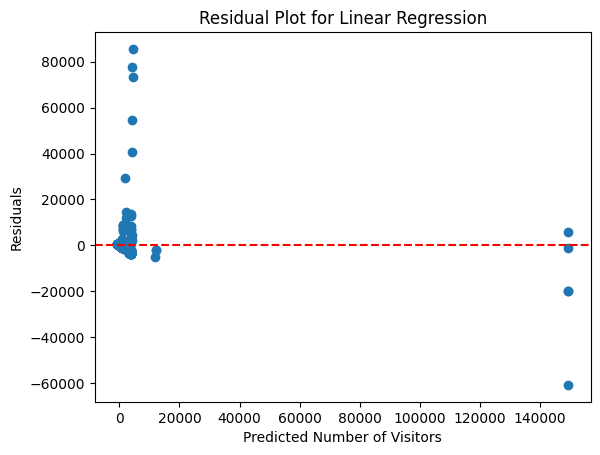

In [103]:
#residual plot
residuals_lr = y_test - y_pred_lr

plt.scatter(y_pred_lr, residuals_lr)
plt.axhline(y = 0, color ='red', linestyle = '--')
plt.xlabel("Predicted Number of Visitors")
plt.ylabel("Residuals")
plt.title("Residual Plot for Linear Regression")
plt.show()

In [104]:
#extraction of model coeffcients
# get  fitted Linear Regression model from the pipeline
fitted_lr_model = lr_pipeline.named_steps['model']

# get feature names after one-hot encoding from the preprocessor in pipeline
ohe_feature_names = lr_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out()

# create a dataframe for coefficients
coeffcients_lr = pd.DataFrame({"Feature": ohe_feature_names, "Coefficient": fitted_lr_model.coef_})
coeffcients_lr

,Feature,Coefficient
0,Port of Entry_NMIA,-61.354337
1,Port of Entry_SIA,61.354337
2,Type of Visit_BUS,40.182066
3,Type of Visit_BUSV,-80.247178
4,Type of Visit_CON,2.464805
...,...,...
110,Month_MARCH,32.861575
111,Month_MAY,-0.982470
112,Month_NOVEMBER,-42.949956
113,Month_OCTOBER,-78.299907


## Comments on Linear Regression Model
The linear regression model was trained using the scaled numeric features
and encoded categorial variables i.e. Port of Entry, Type of Visit, Origin & Month. Linear Regression was selected as a baseline model because of its interpretability and its ability to quantify the linear relationships between predictors and vistor arrivals.

The model was trained on the training dataset and evaluated on the test datset. The performance was assessed using **Mean Absolute Error**, **Root Mean Squared Error** and the **Coeffcient of Determination**.
###Linear Performance Results
The evaluation metrics for this model were:
*   **MAE**: which indicates the avergae error between actual and predicted visitor counts.
*   **RSME**: Penalizes larger errors and reflects the model's pperformance during peak tourism months.
*   **R2 Score**: Represents how much of the variance in visitor arrivals is explained by the model.

In this situation, the predictive capability was moderate but did not capture non linear seasonal tourism trends. Which was expected as linear regression assumes linear relationships between features and the target variable while tourism arrivals often show complex seasonal and market-driven patterns.
### Interpretations

1.   The scatterplot compared predicted and actua values showed visible deviations from the line, indicating that the model underestimates and overestimates visitor counts during certain months.
2.  The resusidual plot confirmed that errors were not normally distributed, suggested that a more flexible model like Random forest may be better suited.

Despite its limitations the Linear Regression Modelprovides:

*   A baseline for comparison
*   Interpretability that supports understanding of general relationships in the data
*   An understanding of the influences of encoded features












##Random Forest Model

In [105]:
# Create the random forst model
rfmodel = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=1)

In [106]:
#use the trained model to make predictions on the unseen data
predictions = rf_pipeline.predict(X_test)

In [107]:
# evaluation of the model
mae_rf = mean_absolute_error(y_test, predictions)
rmse_rf = np.sqrt(mean_squared_error(y_test, predictions))
r2_rf = r2_score(y_test, predictions)

print("Random Forest Performance:")
print(f"Mean Absolute Error (MAE): {mae_rf}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf}")
print(f"R-squared (R2): {r2_rf:4f}")

Random Forest Performance:
Mean Absolute Error (MAE): 74.8770444483315
Root Mean Squared Error (RMSE): 1243.304775885238
R-squared (R2): 0.924560


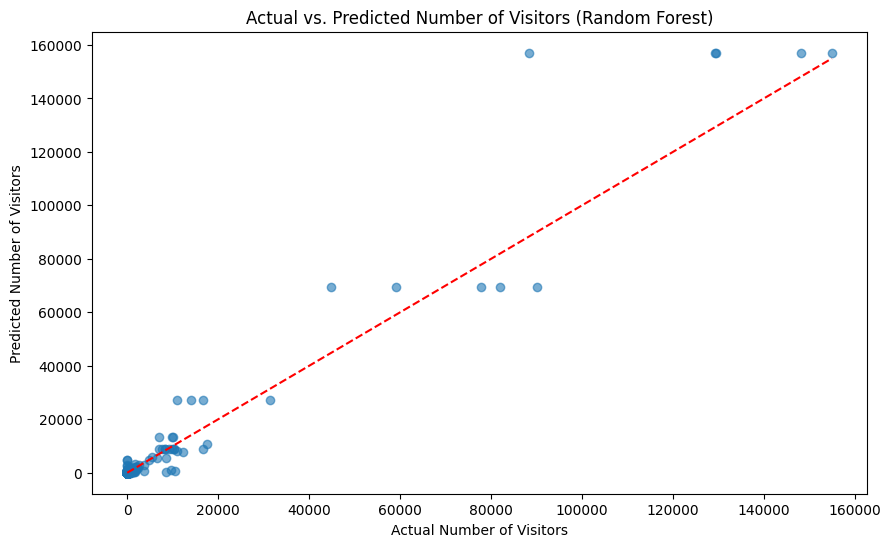

In [108]:
# actual vs predicted plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, alpha = 0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)],'r--')
plt.xlabel("Actual Number of Visitors")
plt.ylabel("Predicted Number of Visitors")
plt.title("Actual vs. Predicted Number of Visitors (Random Forest)")
plt.show()

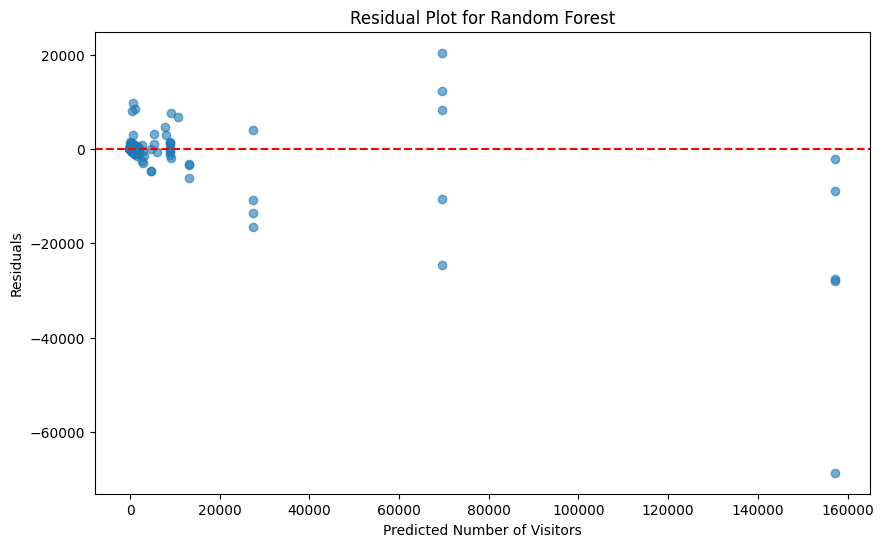

In [109]:
#residuals plot
residuals_rf = y_test - predictions
plt.figure(figsize=(10, 6))
plt.scatter(predictions, residuals_rf, alpha=0.6)
plt.axhline(y = 0, color ='red', linestyle = '--')
plt.xlabel("Predicted Number of Visitors")
plt.ylabel("Residuals")
plt.title("Residual Plot for Random Forest")
plt.show()

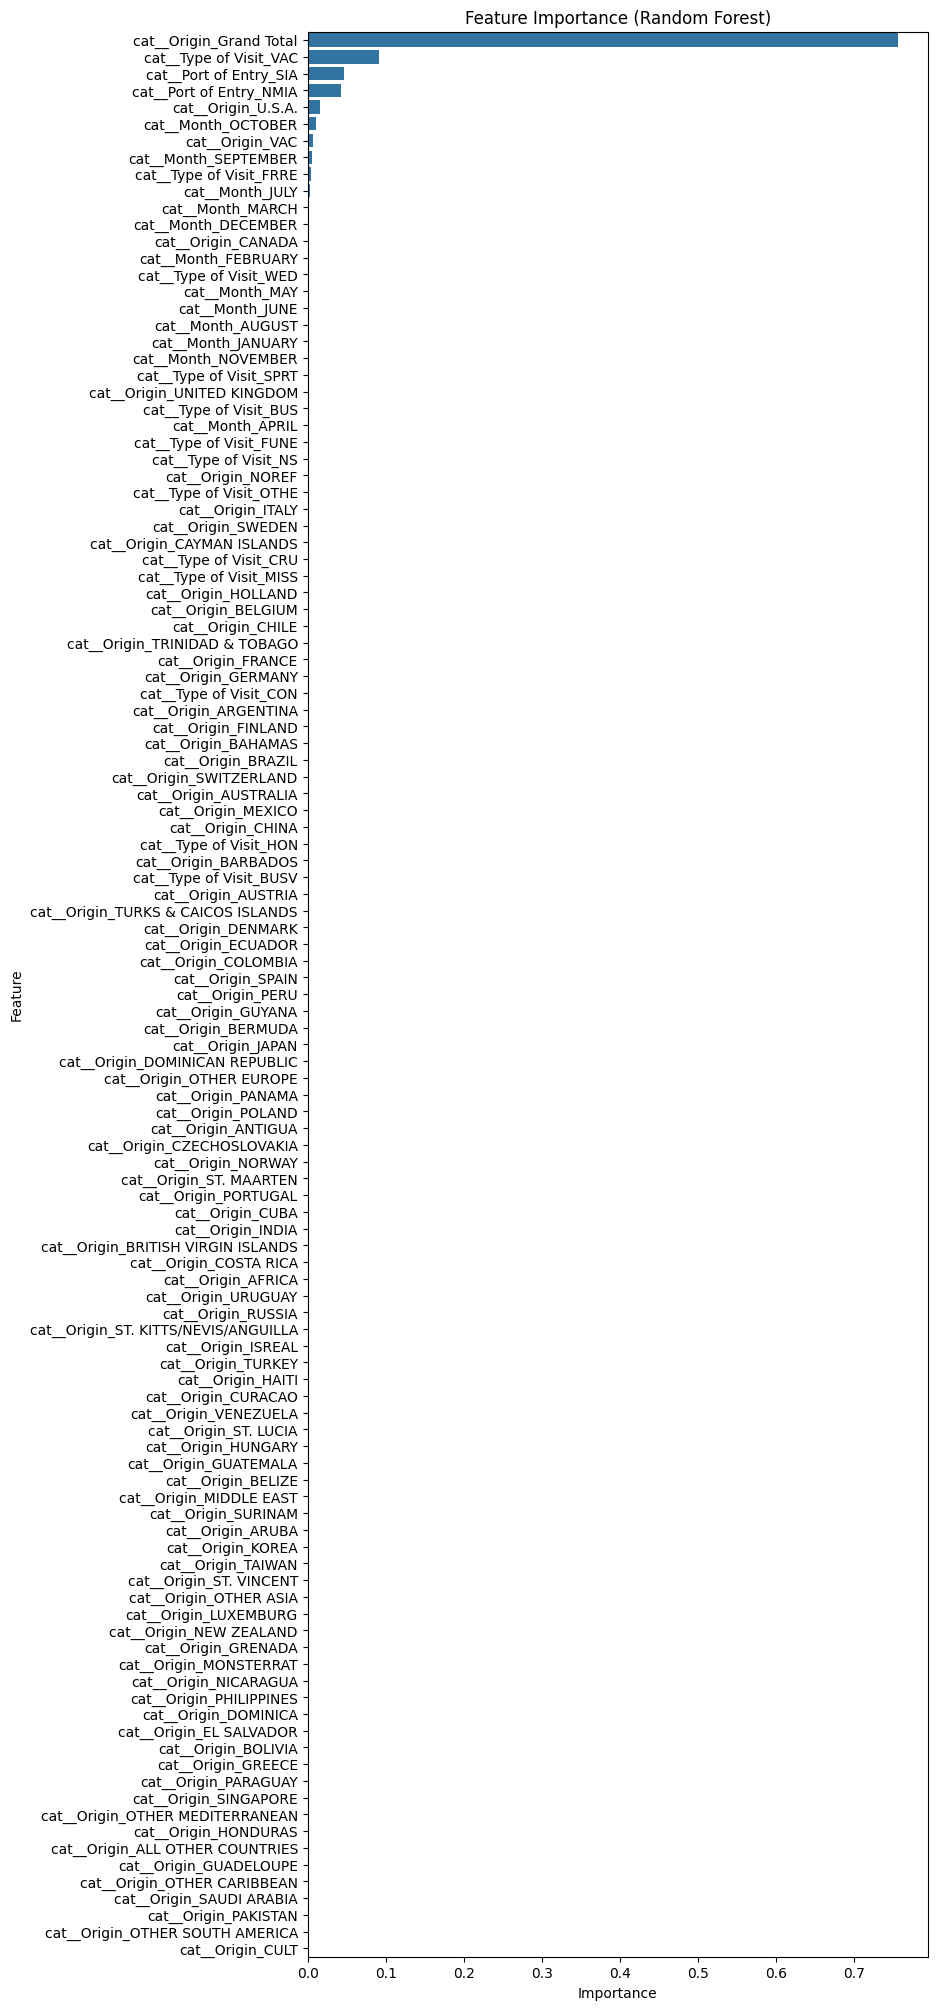

In [110]:
#feature importance plot

# Get the fitted Random Forest model from the pipeline
fitted_rf_model = rf_pipeline.named_steps['model']

# Get the feature names after one-hot encoding from the preprocessor within the pipeline
ohe_feature_names_rf = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

feature_importances = pd.DataFrame({'Feature': ohe_feature_names_rf, 'Importance': fitted_rf_model.feature_importances_})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 25))
sns.barplot(x='Importance', y='Feature', data=feature_importances)
plt.title('Feature Importance (Random Forest)')
plt.show()

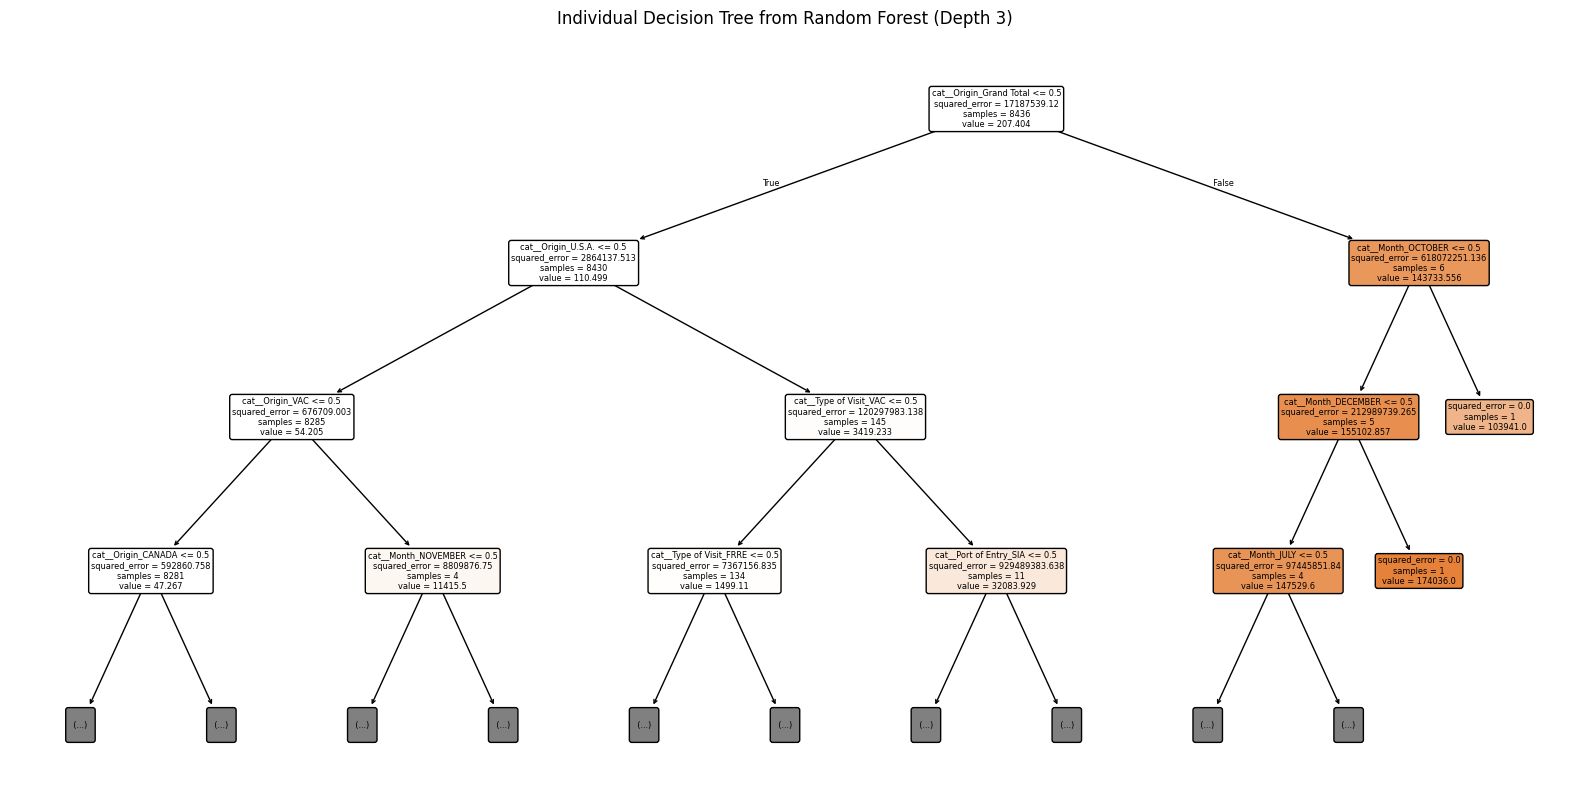

In [111]:
#individual decision tree visualization

# Get the fitted Random Forest model from the pipeline
fitted_rf_model = rf_pipeline.named_steps['model']

# Get feature names after one-hot encoding from the preprocessor
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

plt.figure(figsize=(20, 10)) # Increased figure size for better readability
plot_tree(fitted_rf_model.estimators_[0], feature_names=feature_names, filled=True, rounded=True, max_depth=3)
plt.title('Individual Decision Tree from Random Forest (Depth 3)')
plt.show()

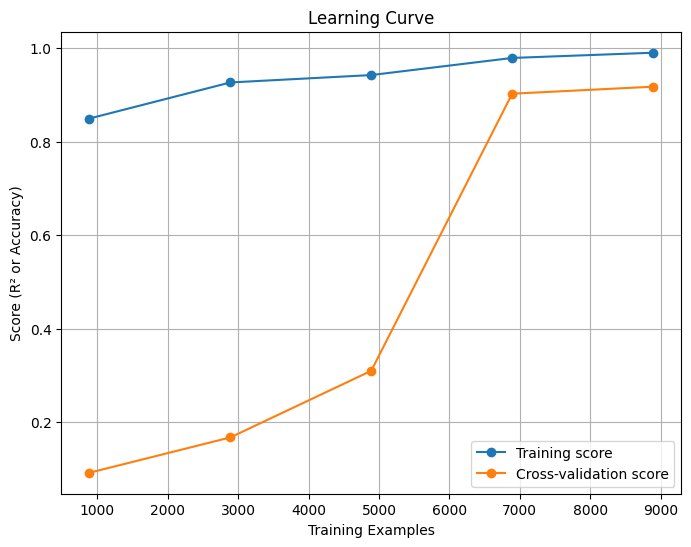

In [112]:
train_sizes, train_scores, test_scores = learning_curve(
    rf_pipeline, X_train, y_train, cv=3, n_jobs=-1, scoring='r2'
)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label="Training score")
plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', label="Cross-validation score")
plt.xlabel("Training Examples")
plt.ylabel("Score (R² or Accuracy)")
plt.title("Learning Curve")
plt.legend()
plt.grid()
plt.show()

#### Comments on Random Forest Model
###### We used the Random Forest Regressor because we’re predicting a number (visitor arrivals). The model builds many small decision trees and averages them, which helps it capture the different patterns in tourism data better than a simple model.

To check how well it works, we used the R² score and error measurements like MAE and RMSE, which basically tell us how close the predictions are to the real visitor numbers.

The model also gives us a feature importance ranking, so we can see which factors—like country of origin or port of entry—have the biggest impact on the predictions.

For clarity, we used visuals such as the Actual vs. Predicted graph and a Residuals Plot to show how the model behaves. We also added a Learning Curve to show how the model improves with more data, and a Decision Tree visualization to give a simple view of how one of the trees makes decisions.

##Model Evaluation

Compare Model Performance Metrics:
- Create a DataFrame to clearly present and compare the Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared (R2) scores for both the Linear Regression and Random Forest models.

- Visualize Model Performance Comparison: Generate a bar chart to visually compare the performance metrics (MAE, RMSE, R2) of the Linear Regression and Random Forest models, including legends for clarity.

- Final Task: Provide a comprehensive summary of the model comparison, highlighting which model performs better based on the evaluation metrics and recommending the most suitable model for visitor arrival forecasting.

### Model Comparision

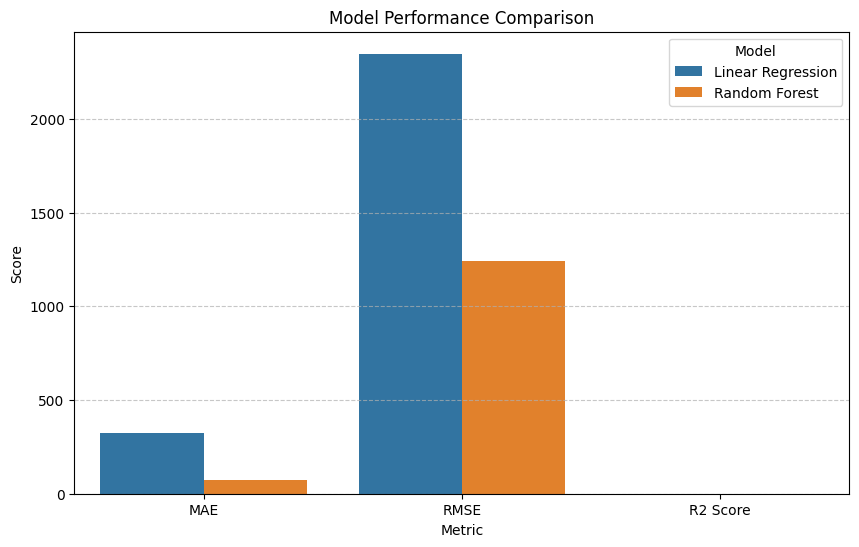

In [113]:
# Define model_performance_df (moved from cell 133d59d1)
performance_data = {
    'Metric': ['MAE', 'RMSE', 'R2 Score'],
    'Linear Regression': [mae_lr, rmse_lr, r2_lr],
    'Random Forest': [mae_rf, rmse_rf, r2_rf]
}
model_performance_df = pd.DataFrame(performance_data)

model_performance_df_melted = pd.melt(model_performance_df, id_vars=['Metric'], var_name='Model', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Score', hue='Model', data=model_performance_df_melted)
plt.title('Model Performance Comparison')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The plot clearly shows that the Random Forest model (in orange) significantly outperforms the Linear Regression model (in blue) across all three metrics. For MAE and RMSE, lower values are better, and the Random Forest bars are much shorter. For the R2 Score, a higher value is better, and the Random Forest bar is significantly taller, almost reaching 1.0, while the Linear Regression bar is very close to zero.

Create a DataFrame to clearly present and compare the Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared (R2) scores for both the Linear Regression and Random Forest models.


In [114]:
performance_data = {
    'Metric': ['MAE', 'RMSE', 'R2 Score'],
    'Linear Regression': [mae_lr, rmse_lr, r2_lr],
    'Random Forest': [mae_rf, rmse_rf, r2_rf]
}

model_performance_df = pd.DataFrame(performance_data)
display(model_performance_df)

,Metric,Linear Regression,Random Forest
0,MAE,323.825625,74.877044
1,RMSE,2348.379371,1243.304776
2,R2 Score,0.730857,0.924560


# Commentary/Justification
Compare model performance metrics by displaying the `model_performance_df` DataFrame and then provide a comprehensive summary of the model comparison, highlighting which model performs better based on the evaluation metrics and recommending the most suitable model for visitor arrival forecasting.

Reasoning: To compare the performance of the Linear Regression and Random Forest models, I will create a dictionary with their respective MAE, RMSE, and R2 scores and then convert it into a DataFrame.

#SHAP (Interpretability)

In [115]:
# Get the fitted Random Forest model from the pipeline
rf_model_fitted = rf_pipeline.named_steps['model']




In [116]:
# Transform X_test using the pipeline's preprocessor
X_test_transformed = rf_pipeline.named_steps['preprocessor'].transform(X_test)



In [117]:
#Converts sparse to dense if required
if hasattr(X_test_transformed, 'toarray'):
    X_test_transformed = X_test_transformed.toarray()



In [118]:
# Create a SHAP TreeExplainer for the fitted Random Forest model
explainer = shap.TreeExplainer(rf_model_fitted)



In [119]:
# Compute SHAP values for the transformed test set
shap_values = explainer.shap_values(X_test_transformed, approximate = True)


In [120]:
#Feature names after encoding
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()



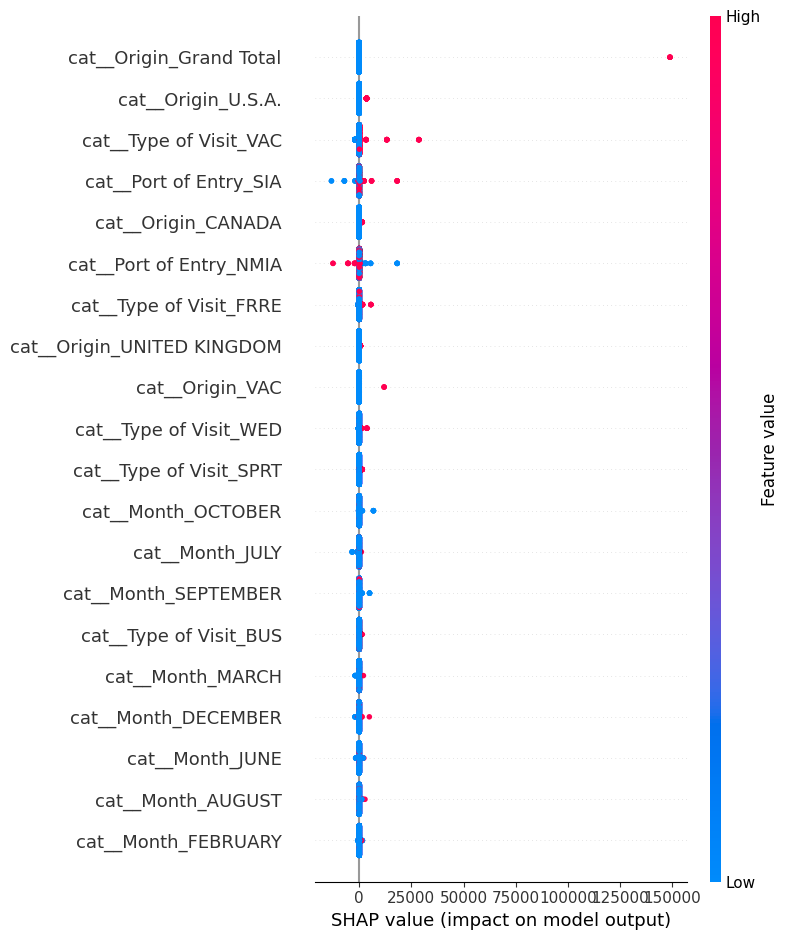

In [121]:
# Global interpretability: Summary plot (beeswarm) showing feature impact distribution
shap.summary_plot(shap_values, X_test_transformed, feature_names = feature_names)


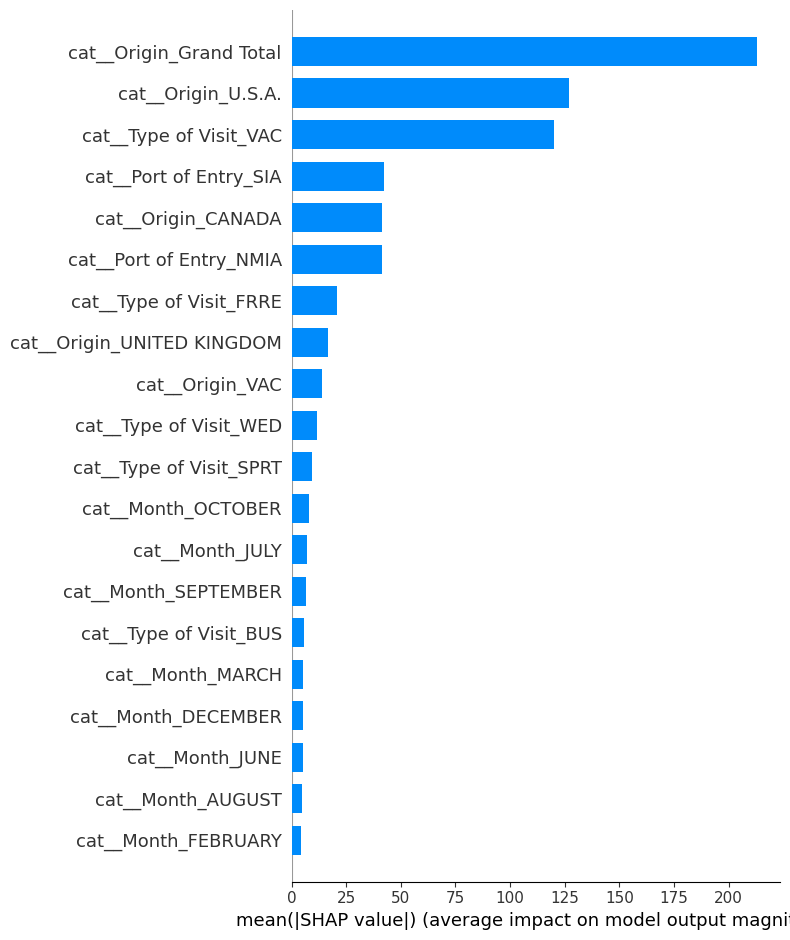

In [122]:

# Global interpretability: Bar plot for mean absolute SHAP values (feature importance)
shap.summary_plot(shap_values, X_test_transformed, feature_names = feature_names, plot_type='bar')


In [123]:

# Local interpretability: Example for a single prediction (e.g., first instance in X_test)
shap.initjs()  # For force plot visualization in Jupyter
shap.force_plot(explainer.expected_value, shap_values[0], X_test_transformed[0], feature_names = feature_names)

In [124]:
#save pipeline to be deployed
with open('rf_pipeline.pkl', 'wb') as file:
    pickle.dump(rf_pipeline, file)

print("Saved pipeline.pkl")

Saved pipeline.pkl


#AI Disclosure
Gemini AI was used to debug and to clarify syntax.